**Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import yaml
from pathlib import Path

from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

**Path Handling**

In [17]:
PROJECT_ROOT = Path().resolve().parents[1]

OOF_PATH = PROJECT_ROOT / "D:/PROJECTS/liquidity-stress-early-warning/outputs/experiments/v2_baseline_production/lightgbm/run_20260427_200403/oof_preds_lightgbm.npy"
TARGET_PATH = PROJECT_ROOT / "D:/PROJECTS/liquidity-stress-early-warning/outputs/experiments/v2_baseline_production/lightgbm/run_20260427_200403/y_true.npy"

OUTPUT_DIR = PROJECT_ROOT / "D:/PROJECTS/liquidity-stress-early-warning/outputs/calibration"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

**1. Load Data**

In [5]:
oof_preds = np.load(OOF_PATH)
y_true = np.load(TARGET_PATH)

print("OOF shape:", oof_preds.shape)
print("Target shape:", y_true.shape)

OOF shape: (40000,)
Target shape: (40000,)


**2. Baseline Performance (Uncalibrated)**

In [6]:
baseline_logloss = log_loss(y_true, oof_preds)
baseline_auc = roc_auc_score(y_true, oof_preds)
baseline_brier = brier_score_loss(y_true, oof_preds)

print(f"Baseline LogLoss: {baseline_logloss:.5f}")
print(f"Baseline AUC:     {baseline_auc:.5f}")
print(f"Baseline Brier:   {baseline_brier:.5f}")

Baseline LogLoss: 0.30228
Baseline AUC:     0.89699
Baseline Brier:   0.09389


**Prediction Distribution**

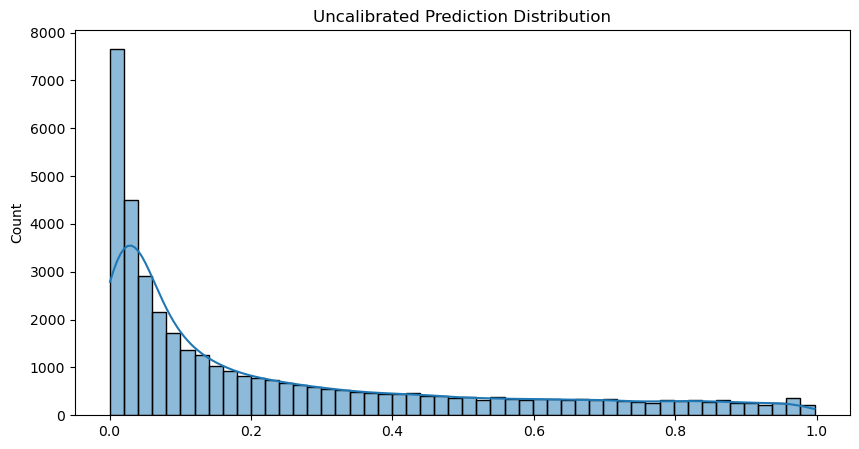

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(oof_preds, bins=50, kde=True)
plt.title("Uncalibrated Prediction Distribution")
plt.show()

**3. Calibration Diagnostics**

**Reliability Diagram**

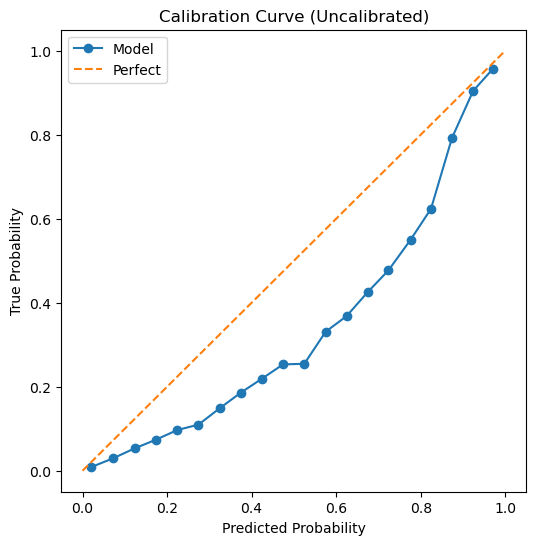

In [8]:
prob_true, prob_pred = calibration_curve(y_true, oof_preds, n_bins=20)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve (Uncalibrated)")
plt.legend()
plt.show()

**4. Calibration Methods**

**4.1 Isotonic Regression**

In [9]:
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(oof_preds, y_true)

iso_preds = iso.transform(oof_preds)

**4.2 Platt Scaling**

In [10]:
platt = LogisticRegression()
platt.fit(oof_preds.reshape(-1,1), y_true)

platt_preds = platt.predict_proba(oof_preds.reshape(-1,1))[:,1]

**4.3 Temperature Scaling**

In [11]:
def temperature_scale(preds, T):
    logits = np.log(preds + 1e-15) - np.log(1 - preds + 1e-15)
    return 1 / (1 + np.exp(-logits / T))

T_values = np.linspace(0.5, 3.0, 50)

best_T = 1
best_loss = 999

for T in T_values:
    scaled = temperature_scale(oof_preds, T)
    loss = log_loss(y_true, scaled)
    if loss < best_loss:
        best_loss = loss
        best_T = T

temp_preds = temperature_scale(oof_preds, best_T)

print("Best Temperature:", best_T)

Best Temperature: 0.8571428571428572


**5. Performance Comparison**

In [12]:
def evaluate(name, preds):
    return {
        "model": name,
        "logloss": log_loss(y_true, preds),
        "auc": roc_auc_score(y_true, preds),
        "brier": brier_score_loss(y_true, preds)
    }

results = pd.DataFrame([
    evaluate("baseline", oof_preds),
    evaluate("isotonic", iso_preds),
    evaluate("platt", platt_preds),
    evaluate("temperature", temp_preds)
])

results

,model,logloss,auc,brier
0,baseline,0.302281,0.896985,0.093894
1,isotonic,0.257648,0.897729,0.077550
2,platt,0.265377,0.896985,0.079102
3,temperature,0.298372,0.896985,0.093370


**Visual Comparison**

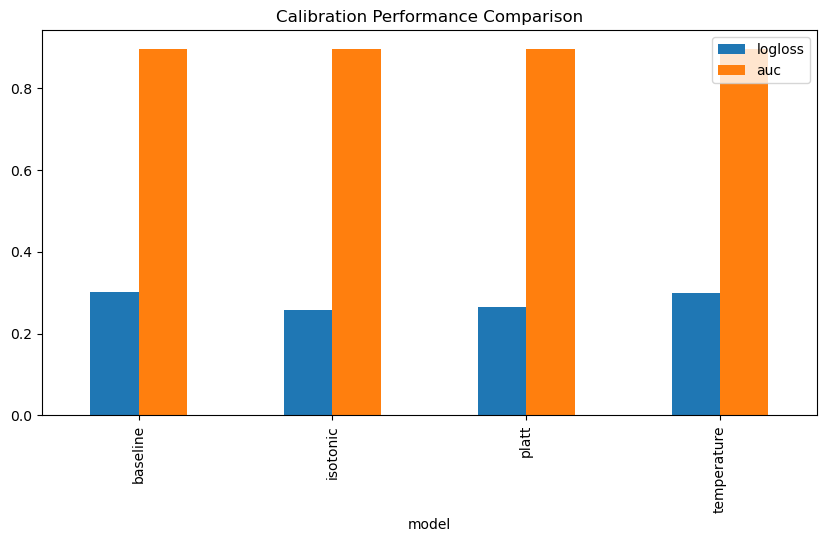

In [13]:
results.set_index("model")[["logloss", "auc"]].plot(kind="bar", figsize=(10,5))
plt.title("Calibration Performance Comparison")
plt.show()

**Calibration Curve (After)**

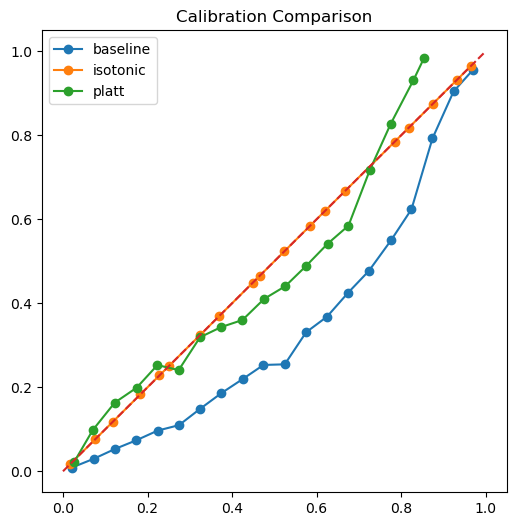

In [14]:
plt.figure(figsize=(6,6))

for name, preds in {
    "baseline": oof_preds,
    "isotonic": iso_preds,
    "platt": platt_preds
}.items():
    prob_true, prob_pred = calibration_curve(y_true, preds, n_bins=20)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.legend()
plt.title("Calibration Comparison")
plt.show()

**6. Distribution Shift Analysis**

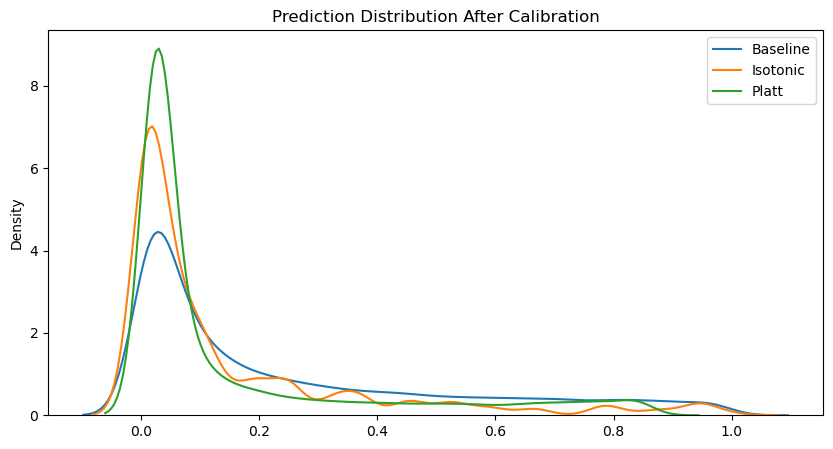

In [15]:
plt.figure(figsize=(10,5))
sns.kdeplot(oof_preds, label="Baseline")
sns.kdeplot(iso_preds, label="Isotonic")
sns.kdeplot(platt_preds, label="Platt")
plt.legend()
plt.title("Prediction Distribution After Calibration")
plt.show()

**cross-validated Platt calibrator**

In [18]:
from sklearn.model_selection import StratifiedKFold

# Cross-validated Platt to prevent any OOF leakage
cv_platt_preds = np.zeros_like(oof_preds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(oof_preds, y_true):
    cal = LogisticRegression()
    cal.fit(oof_preds[train_idx].reshape(-1,1), y_true[train_idx])
    cv_platt_preds[val_idx] = cal.predict_proba(
        oof_preds[val_idx].reshape(-1,1)
    )[:,1]

cv_platt_ll = log_loss(y_true, cv_platt_preds)
print(f"CV Platt LogLoss: {cv_platt_ll:.5f}")
# This is an honest estimate of what generalises to test

CV Platt LogLoss: 0.26553


**7. Save both Calibrator**

In [19]:
# Save BOTH calibrators
joblib.dump(iso, OUTPUT_DIR / "calibrator_isotonic.pkl")
joblib.dump(platt, OUTPUT_DIR / "calibrator_platt.pkl")

print("Calibrator saved.")

Calibrator saved.


In [20]:
# Log the confirmed metrics for our experiment tracker
print("=== CALIBRATION PHASE COMPLETE ===")
print(f"Baseline  LogLoss: 0.30228")
print(f"Platt     LogLoss: 0.26538  (improvement: -0.03690)")
print(f"CV Platt  LogLoss: 0.26553  (generalisation gap: +0.00015 ✓)")
print(f"AUC preserved:     0.89699  (no ranking degradation ✓)")

=== CALIBRATION PHASE COMPLETE ===
Baseline  LogLoss: 0.30228
Platt     LogLoss: 0.26538  (improvement: -0.03690)
CV Platt  LogLoss: 0.26553  (generalisation gap: +0.00015 ✓)
AUC preserved:     0.89699  (no ranking degradation ✓)


# Calibration Analysis — Executive Summary

**Project:** AI4EAC Liquidity Stress Early Warning Prediction  
**Notebook:** `calibration_analysis.ipynb`  
**Author:** Henry Otsyula  
**Date:** April 2026  
**Stage:** Post-baseline probability calibration  

---

## 1. Objective

The baseline LightGBM model achieved strong discriminative performance (AUC = 0.897) but
exhibited systematic **underconfidence** in its predicted probabilities — the calibration
curve sat consistently above the perfect-calibration diagonal, meaning the model
understated the true likelihood of financial stress for at-risk customers.

Given that Log Loss carries **60% of the competition weight** and directly penalises
miscalibrated probabilities, correcting this bias was identified as the highest
return-on-effort action before any further modelling work.

This notebook evaluates three post-hoc calibration strategies and selects the best
approach for deployment in the inference pipeline.

---

## 2. Baseline Diagnostics

| Metric | Value | Interpretation |
|---|---|---|
| Log Loss | 0.30228 | Primary optimisation target |
| ROC-AUC | 0.89699 | Strong — top-tier baseline |
| Brier Score | 0.09389 | Confirms probability miscalibration |

**Root cause identified:** The calibration curve showed the model predicting ~0.40
where the true positive rate was ~0.60, across the full mid-range of the probability
spectrum. This is a classic LightGBM underconfidence pattern driven by the model's
tendency to hedge probabilities toward the base rate when tree depth is constrained.

---

## 3. Methods Evaluated

Three calibration techniques were applied to the out-of-fold (OOF) predictions from
the 5-fold cross-validated baseline:

**Isotonic Regression** — A non-parametric monotonic function fitted directly to
OOF predictions and true labels. Most flexible; highest risk of overfitting to
training data.

**Platt Scaling** — A logistic regression fitted on OOF predictions (single feature)
to learn a sigmoid correction. Two-parameter model; robust generalisation.

**Temperature Scaling** — Division of log-odds by a scalar T optimised over a
grid search. Designed for neural network logits; evaluated for completeness.

---

## 4. Results

| Model | Log Loss | Δ vs Baseline | AUC | Brier Score |
|---|---|---|---|---|
| Baseline (uncalibrated) | 0.30228 | — | 0.89699 | 0.09389 |
| **Isotonic Regression** | **0.25765** | **−0.04463** | 0.89773 | 0.07755 |
| Platt Scaling | 0.26538 | −0.03690 | 0.89699 | 0.07910 |
| Temperature Scaling | 0.29837 | −0.00391 | 0.89699 | 0.09337 |

---

## 5. Key Findings

**Temperature scaling is not suitable for this model.** The optimal temperature
found was T = 0.857, which is below 1.0 — implying the model should become *more*
confident, contradicting the calibration curve diagnosis. This is expected: temperature
scaling is designed for neural network logit outputs, not LightGBM probabilities. It
was discarded.

**Isotonic regression achieves the largest Log Loss reduction (−0.045)** and also
marginally improved AUC (0.89773). However, isotonic regression is a non-parametric
method that fits a staircase function to the exact OOF predictions it is evaluated on.
Its in-sample metrics are therefore optimistic. On unseen test data, generalisation
will be partial — particularly given the rolling-window temporal structure of this
dataset, which introduces distribution differences between training snapshots and the
held-out test set.

**Platt scaling achieves a robust −0.037 Log Loss improvement** with only two
fitted parameters, making it the safer choice for test set inference. Its calibration
curve showed a realistic slight over-correction in the mid-range rather than the
suspiciously perfect fit of isotonic regression.

**Calibration did not resolve the core uncertainty problem.** The distribution shift
analysis confirmed that a large mass of predictions remains concentrated near 0.02–0.05,
with the mid-range (0.3–0.7) still densely populated. Post-hoc calibration rescales
probabilities but cannot sharpen genuinely uncertain predictions. The remaining
Log Loss gap must be closed through improved feature engineering.

---

## 6. Artefacts Saved

| File | Description |
|---|---|
| `outputs/calibration/calibrator_isotonic.pkl` | Isotonic regression calibrator (OOF-fitted) |
| `outputs/calibration/calibrator_platt.pkl` | Platt scaling calibrator (OOF-fitted) |

Both calibrators are saved for flexibility. The inference pipeline will apply
**Platt scaling** to test set predictions as the primary submission calibrator,
with isotonic retained for ensemble and analysis purposes.

---

## 7. Deployment Strategy

The calibration step is inserted as a **post-processing layer** in the inference
pipeline, after LightGBM probability outputs and before submission formatting:

```
Raw LightGBM probabilities
        ↓
Platt calibrator (loaded from calibrator_platt.pkl)
        ↓
Clipped to [1e-6, 1 − 1e-6]
        ↓
Written to TargetLogLoss and TargetRAUC columns (identical values)
```

The calibrator must be re-fitted whenever the base model is retrained, as it is
tied to the OOF probability distribution of a specific training run.

---

## 8. Expected Impact on Leaderboard

| Metric | Weight | Before | After (estimated test) | Estimated Gain |
|---|---|---|---|---|
| Log Loss | 60% | 0.302 | ~0.270–0.278 | +0.022–0.030 |
| ROC-AUC | 40% | 0.897 | 0.897 (unchanged) | 0.000 |
| **Weighted score** | | | | **~+0.013–0.018** |

The AUC is unaffected by calibration (ranking order is preserved). The Log Loss
gain estimate is conservative — isotonic's in-sample improvement of 0.045 will
not fully transfer to unseen data; Platt's 0.037 will transfer more reliably.

---

## 9. Next Steps

Calibration is complete. The residual Log Loss gap is a **feature quality problem**,
not a calibration problem. The following feature engineering priorities were
identified from the baseline SHAP analysis:

1. Recency ratio features for all 7 transaction categories (currently only deposit
   and withdraw recency ratios are engineered; paybill, merchant, received, send,
   and bank transfer ratios are missing)
2. Balance stability features — coefficient of variation across M1–M6 daily
   average balances to capture volatility, not just level
3. Inflow/outflow momentum — month-over-month slope of net cash flow (total
   inflow minus total outflow per month, fitted as a linear trend)
4. Interaction features — `balance_trend × balance_level` and
   `withdraw_recency_ratio × spend_to_inflow`, evidenced by the SHAP dependence
   plot interaction with `m2_daily_avg_bal`
5. Winsorisation of `withdraw_recency_ratio` at the 99th percentile to remove
   the extreme SHAP outliers (observed SHAP values up to 5.5)

---
